In [ ]:
pip install deepface opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.2 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
import base64
from IPython.display import display, HTML, Image
from deepface import DeepFace
import os
import csv

25-10-14 08:43:17 - Directory /root/.deepface has been created
25-10-14 08:43:17 - Directory /root/.deepface/weights has been created


In [ ]:
os.makedirs('uploads', exist_ok=True)
os.makedirs('ref_Photos', exist_ok=True)

print("✓ Folders created: 'uploads' and 'ref_Photos'")

✓ Folders created: 'uploads' and 'ref_Photos'


In [ ]:
print("Upload reference images (named as StudentID.jpg/png):")
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(f'ref_Photos/{filename}', 'wb') as f:
        f.write(content)
    print(f"✓ Saved: {filename}")

Upload reference images (named as StudentID.jpg/png):


Saving spriha.jpg to spriha.jpg
✓ Saved: spriha.jpg


In [ ]:
def load_reference_images():
    """Load and store cropped faces from all reference images"""
    faces = {}
    reference_folder = 'ref_Photos'

    if not os.path.exists(reference_folder):
        return faces

    for filename in os.listdir(reference_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            student_id = os.path.splitext(filename)[0]
            filepath = os.path.join(reference_folder, filename)
            try:
                img = cv2.imread(filepath)
                if img is not None:
                    detections = DeepFace.extract_faces(
                        img_path=filepath,
                        detector_backend='opencv',
                        enforce_detection=False
                    )
                    if detections and len(detections) > 0:
                        face = detections[0]["face"]
                        # Convert grayscale to RGB if needed
                        if face.dtype != np.uint8:
                            face = (face * 255).astype(np.uint8) if face.max() <= 1.0 else face.astype(np.uint8)
                        faces[student_id] = face
                        print(f"✓ Loaded face for student ID: {student_id}")
                    else:
                        print(f"✗ No face detected in: {filename}")
                else:
                    print(f"✗ Could not load image: {filename}")
            except Exception as e:
                print(f"✗ Error processing {filename}: {e}")

    return faces

reference_faces = load_reference_images()
print(f"\n✓ Total reference faces loaded: {len(reference_faces)}")

✓ Loaded face for student ID: spriha

✓ Total reference faces loaded: 1


Upload class photo for attendance:


Saving Photo on 12-10-25 at 15.23.jpg to Photo on 12-10-25 at 15.23.jpg


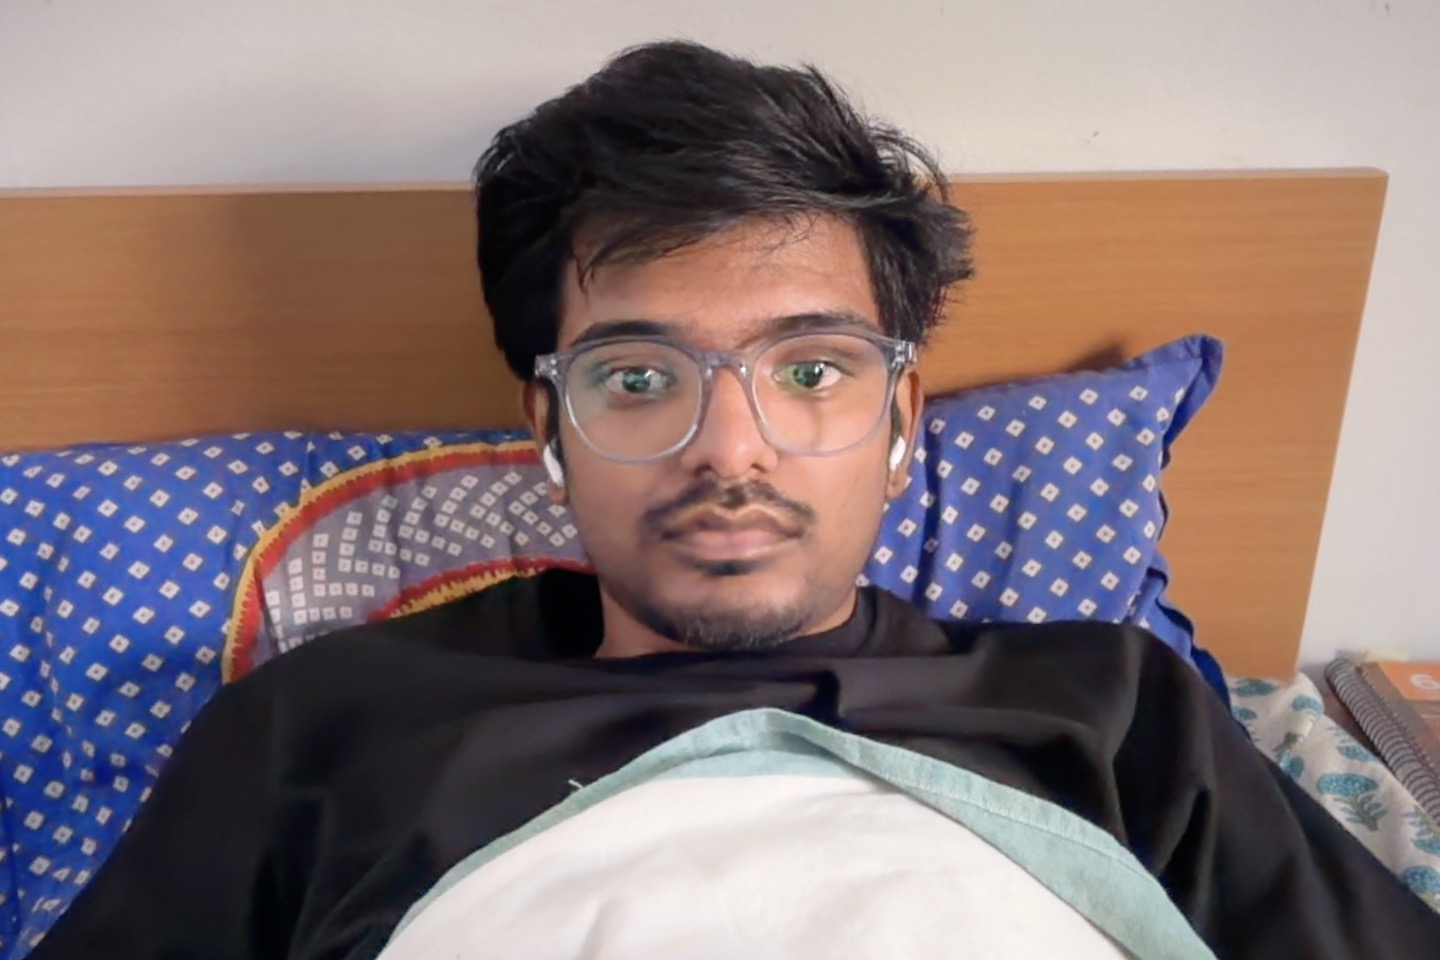

In [ ]:
print("Upload class photo for attendance:")
uploaded_photo = files.upload()
photo_filename = list(uploaded_photo.keys())[0]

with open(f'uploads/{photo_filename}', 'wb') as f:
    f.write(uploaded_photo[photo_filename])

# Display uploaded photo
display(Image(f'uploads/{photo_filename}'))

In [ ]:
def process_attendance(photo_path, reference_faces):
    """Process attendance from uploaded photo"""
    img = cv2.imread(photo_path)
    if img is None:
        print("Error: Could not load image")
        return []

    # Detect faces in class photo
    try:
        detections = DeepFace.extract_faces(
            img_path=photo_path,
            detector_backend='opencv',
            enforce_detection=False
        )
    except Exception as e:
        print(f"Error detecting faces: {e}")
        return []

    print(f"Detected {len(detections)} faces in class photo")

    attendance_records = []
    matched_students = set()

    # Match each detected face with reference faces
    for idx, detection in enumerate(detections):
        face = detection["face"]

        # Convert to proper format
        if face.dtype != np.uint8:
            face = (face * 255).astype(np.uint8) if face.max() <= 1.0 else face.astype(np.uint8)

        best_match = None
        best_distance = float('inf')

        # Compare with all reference faces
        for student_id, ref_face in reference_faces.items():
            if student_id in matched_students:
                continue

            try:
                result = DeepFace.verify(
                    img1_path=face,
                    img2_path=ref_face,
                    model_name='VGG-Face',
                    detector_backend='skip',
                    enforce_detection=False
                )

                if result['verified'] and result['distance'] < best_distance:
                    best_distance = result['distance']
                    best_match = student_id
            except Exception as e:
                continue

        if best_match:
            matched_students.add(best_match)
            attendance_records.append({
                'Student_ID': best_match,
                'Timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'Status': 'Present',
                'Confidence': f"{(1 - best_distance) * 100:.2f}%"
            })
            print(f"✓ Matched: {best_match} (Confidence: {(1-best_distance)*100:.2f}%)")

    return attendance_records

# Process the uploaded photo
attendance = process_attendance(f'uploads/{photo_filename}', reference_faces)


Detected 1 faces in class photo


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5


25-10-14 08:48:07 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


100%|██████████| 580M/580M [00:01<00:00, 295MB/s]


In [ ]:
if attendance:
    df = pd.DataFrame(attendance)
    print("\n📋 ATTENDANCE RECORD:")
    print("=" * 60)
    display(df)

    # Save to CSV
    csv_filename = f'attendance_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"\n✓ Saved to: {csv_filename}")

    # Download CSV
    files.download(csv_filename)
else:
    print("❌ No matches found")

❌ No matches found


In [ ]:
print("\n👥 PRESENT STUDENTS:")
print("=" * 60)
for record in attendance:
    print(f"• {record['Student_ID']} - {record['Confidence']} confidence")


👥 PRESENT STUDENTS:
